# UPA - 3.projekt

# 1.časť

In [1]:
#Modules import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [2]:
# Load the dataframe
df = pd.read_csv("data.csv")
df.head()

,url,name,price,quantity_box,quantity_carton,color,material,dipping
0,https://www.ardon.cz/kombinovane-rukavice-ardo...,Kombinované rukavice ARDON®ELTON,69.43,12.0,72.0,žlutá,bavlna,NaN
1,https://www.ardon.cz/macene-rukavice-ardonsafe...,Máčené rukavice ARDON®PERRY UNI,15.67,NaN,NaN,NaN,NaN,NaN
2,https://www.ardon.cz/macene-rukavice-ardonsafe...,Máčené rukavice ARDON®RANDY,43.44,12.0,120.0,bílá,polyester,latex
3,https://www.ardon.cz/kombinovane-rukavice-ardo...,Kombinované rukavice ARDON®ELTON,60.50,12.0,72.0,žlutá,bavlna,NaN
4,https://www.ardon.cz/zimni-rukavice-ardon-r-ho...,Zimní rukavice ARDON®HOBBY REFLEX WINTER,104.15,12.0,120.0,reflexní,kůže,NaN


## Explorativná analýza

Pre zvolenú datovú sadu z prvého projektu najskôr prevedieme exploratívnu analýzu.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              150 non-null    object 
 1   name             150 non-null    object 
 2   price            150 non-null    float64
 3   quantity_box     127 non-null    float64
 4   quantity_carton  127 non-null    float64
 5   color            140 non-null    object 
 6   material         142 non-null    object 
 7   dipping          83 non-null     object 
dtypes: float64(3), object(5)
memory usage: 9.5+ KB


Datová sada obsahuje 7 následujúcich atribútov:  
url: unikátny identifikátor webovej stránky každej rukavice (kategorický)  
name: Názov rukavíc (kategorický)  
price: Cena rukavíc (kvantitatívny)  
quantity_box: Počet rukavíc v balení (kvantitatívny)  
quantity_carton Počet rukavíc v kartóne (kvantitatívny)  
color: Farba rukavíc (kategorický)  
material: Materiál z ktorého sú rukavice vyrobené (kategorický)  
dipping: Máčanie rukavíc (kategorický)  

Celkovo datová sada obsahuje 3 kvantitatívne a 5 kategorických atribútov.

V datovej sade sa nachádzajú aj chýbajúce hodnoty, kde najviac ich chýba v máčaní (dipping).

In [4]:
print(df.describe())

# Additional details: range, unique values, etc.
for column in df.select_dtypes(include=['float64', 'int64']).columns:
    print(f"\nColumn: {column}")
    print(f"Range: {df[column].min()} - {df[column].max()}")
    print(f"Unique values: {df[column].nunique()}")

             price  quantity_box  quantity_carton
count   150.000000    127.000000       127.000000
mean    143.714333     11.850394       132.881890
std     146.519208      1.031863        96.690524
min       5.960000      1.000000        60.000000
25%      43.937500     12.000000        72.000000
50%     108.005000     12.000000       120.000000
75%     195.245000     12.000000       144.000000
max    1188.190000     12.000000       600.000000

Column: price
Range: 5.96 - 1188.19
Unique values: 136

Column: quantity_box
Range: 1.0 - 12.0
Unique values: 3

Column: quantity_carton
Range: 60.0 - 600.0
Unique values: 9


Analyzovali sme kvantitatívne atribúty v dátovej sade s cieľom získať prehľad o ich štatistických vlastnostiach.

Atribúty ceny(price) vykazujú variabilitu pravdepodobne v dôsledku prítomnosti odľahlých hodnôt. Atribút množstva v krabici(quantity_box) vykazuje značne obmedzený počet unikátných hodnôt, tento fakt môžeme vidieť aj v kvantiloch, kedy obsahujú iba maximálnu hodnotu. Atribút množstva v kártóne (quantity_carton) má lepšiu variabilitu, avšak počet unikátnych hodnôt je tiež nízky.

Chýbajúce hodnoty pre počty sú rovnaké, kde obom atribútom chýba 23 hodnôt. 

In [5]:
# Check unique and most frequent values in categorical columns
for column in df.select_dtypes(include=['object']).columns:
    print(f"\nColumn: {column}")
    print(f"Unique values: {df[column].nunique()}")
    print("Most frequent values:")
    print(df[column].value_counts().head(5))


Column: url
Unique values: 150
Most frequent values:
url
https://www.ardon.cz/kombinovane-rukavice-ardon-r-elton-s-prodejni-etiketou    1
https://www.ardon.cz/atg-r-macene-rukavice-maxidry-r-56-425                    1
https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-oiltm-44-305          1
https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-oiltm-44-504          1
https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-oiltm-44-505          1
Name: count, dtype: int64

Column: name
Unique values: 147
Most frequent values:
name
Kombinované rukavice ARDON®ELTON                 2
Svářečské rukavice ARDON®COY                     2
Máčené rukavice ARDON®PERRY UNI                  2
Zimní rukavice ARDON®Winfine                     1
ATG® protiřezné rukavice MaxiCut® Oil™ 44-305    1
Name: count, dtype: int64

Column: color
Unique values: 22
Most frequent values:
color
modrá     28
šedá      25
zelená    19
bílá      15
žlutá     12
Name: count, dtype: int64

Column: material


Teraz zanalyzujeme kategorické premenné.

Atribút url má všetky hodnoty unikátne, čo potvrdzuje, že slúži ako jednoznačný identifikátor každého produktu v dátovej sade.
Atribút názvu obsahuje tri duplikátne hodnoty, ktoré predstavujú rovnaké produkty. Po bližšej analýze sme zistili, že tieto produkty majú niektoré atribúty, ako napríklad cena, rozdielne, čo môže naznačovať odlišné varianty alebo rôzne balenia toho istého produktu.
Ostatné atribúty majú dobrú variabilitu s dostatočným počtom unikátnych hodnôt.

## Prieskum dát pomocou grafov

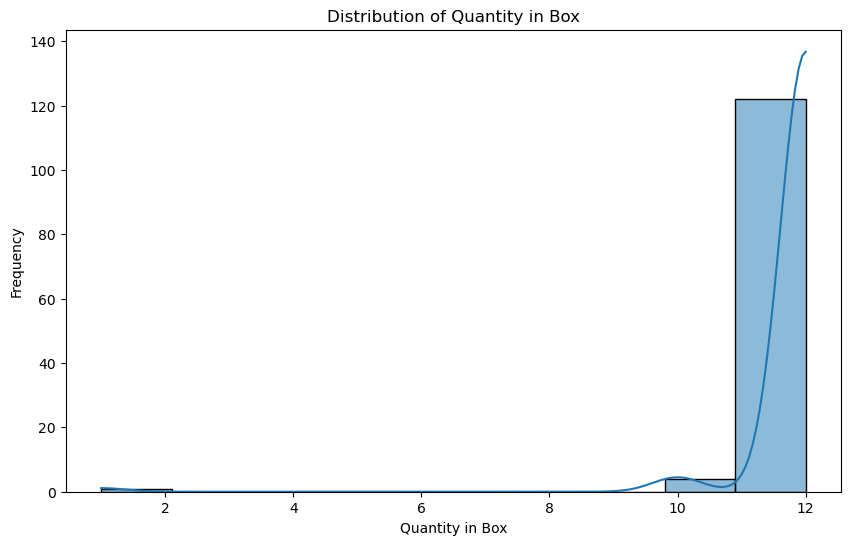

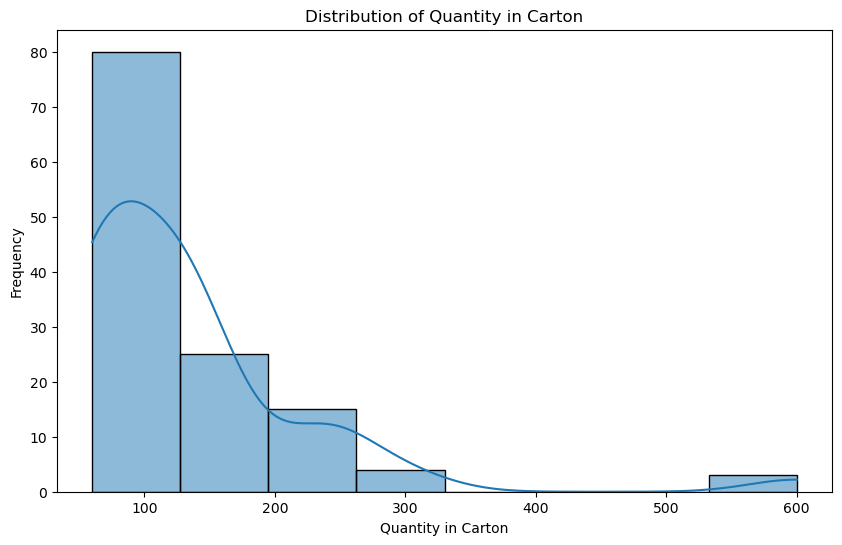

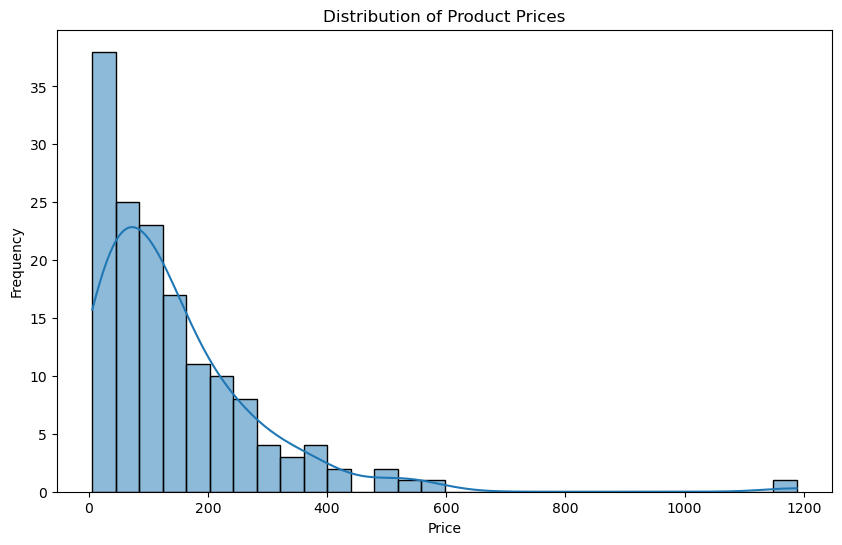

In [6]:
# Histogram graphs
plt.figure(figsize=(10, 6))
sns.histplot(df['quantity_box'], kde=True, bins=10)
plt.title('Distribution of Quantity in Box')
plt.xlabel('Quantity in Box')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['quantity_carton'], kde=True, bins=8)
plt.title('Distribution of Quantity in Carton')
plt.xlabel('Quantity in Carton')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Grafy histogramu nám vizualizujú distribúciu dát, pričom ich hodnoty zodpovedajú našim úvahám pri štatistickej analýze.

Graf počtu rukavíc v krabici(quantity_box) ukazuje veľmi nízku variabilitu hodnôt, pričom väčšina vzoriek dosahuje maximálnu hodnotu (12 rukavíc v krabici). Zvyšné hodnoty mimo tohto rozsahu sú extrémne zriedkavé a takmer nevýznamné.

Graf počtu rukavíc v kartóne(quantity_carton) má väčšiu variabilitu ako môžeme vidieť. Väčšina dát sa koncentruje v rozmedzí 100–300 rukavíc na kartón, pričom zopár vzoriek dosahuje hodnoty až okolo 600. Tento graf tiež vykazuje prítomnosť vyšších hodnôt, ktoré by mohli byť považované za potenciálne outliery.

Graf ceny(price) dosahuje vysokú variabilitu a má väčšie rozmedzie hodnôt, približne do ceny 600. Rovnako zopár vzorkov dosahuje hodnoty v rozmedzí 1100-1200. Tieto hodnoty sa nám pravdepodobne v nasledujúcich grafoch vyobrazia ako outliery.

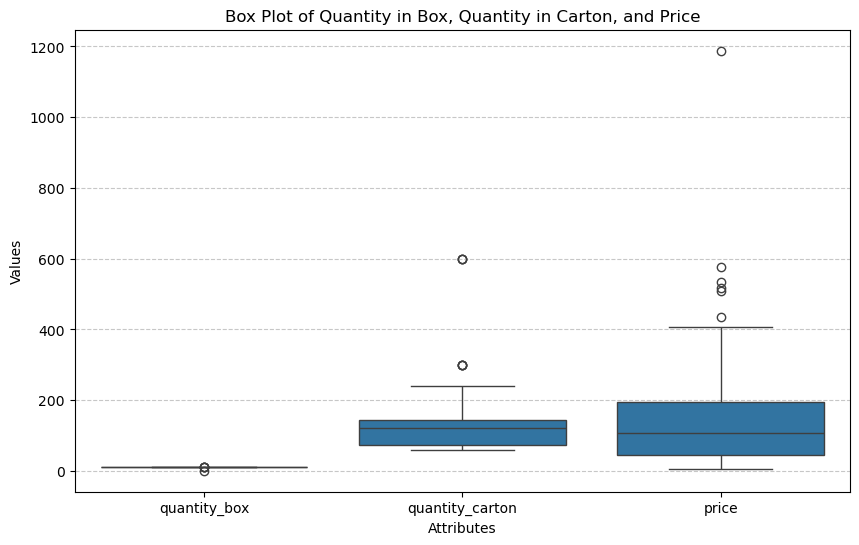

In [7]:
df_melted = df[['quantity_box', 'quantity_carton', 'price']].melt(var_name='Attribute', value_name='Value')

# Create a box plot with a log scale on the y-axis
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attribute', y='Value', data=df_melted)

# Set the title and labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Box Plot of Quantity in Box, Quantity in Carton, and Price')
plt.xlabel('Attributes')
plt.ylabel('Values')

plt.show()

Boxplot graf oproti obyčajnému histogramu poskytuje detailnejší pohľad na dáta tým, že umožňuje vizualizáciu outlierov, mediánu a rozsahu medzi prvým a tretím kvartilom.

Atribút počtu rukavíc v krabici(quantity_box) vykazuje, že skoro všetky dáta majú jednu zhodnú hodnotu bez viditeľnej variability. To naznačuje konštantnosť tohoto atribútu.

Atribút počtu rukavíc v kartóne(quantity_carton) vykazuje vyššiu variabilitu v porovnaní s predchádzajúcim atribútom. "Krabica" ukazuje rozptyl medzi prvým a tretím kvartilom, pričom odľahlé hodnoty (outliery) sú jasne zobrazené ako body nad rozsahom, ako bolo diskutované v predchádzajúcom grafe.

Atribút ceny(price) vykazuje najväčší rozptyl hodnôt. Vidíme najvyšší počet outlierov, hlavne v intervale 600–1200, čo naznačuje veľkú medzeru medzi bežnými hodnotami a extrémne vysokými cenami.

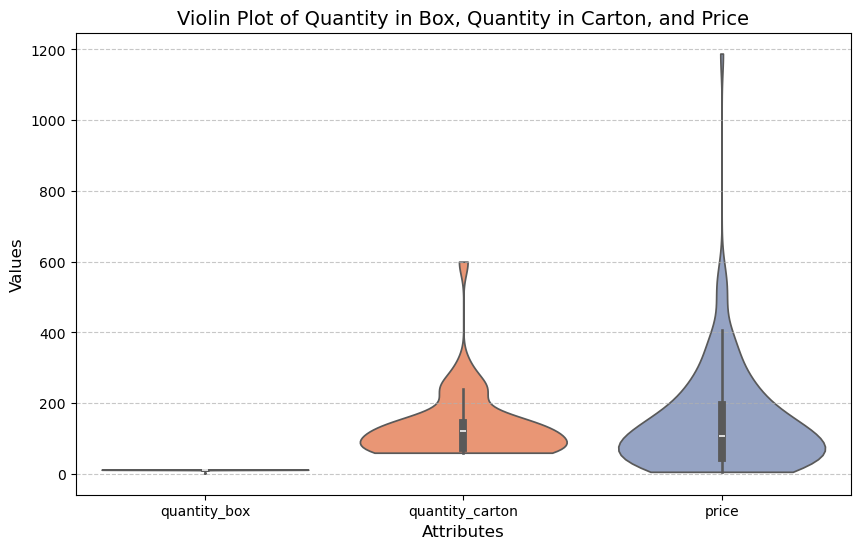

In [8]:
df_melted = df[['quantity_box', 'quantity_carton', 'price']].melt(var_name='Attribute', value_name='Value')

plt.figure(figsize=(10, 6))

sns.violinplot(
    x='Attribute', 
    y='Value', 
    hue='Attribute',
    data=df_melted, 
    palette='Set2',  # For nice visual colors than default
    cut=0            # Prevent violins from extending beyond data range
)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Violin Plot of Quantity in Box, Quantity in Carton, and Price', fontsize=14)
plt.xlabel('Attributes', fontsize=12)
plt.ylabel('Values', fontsize=12)

# Display the plot
plt.show()

Na husľovom grafe môžeme vidieť distribúciu rovnakých dát ako v krabicovom. 

Atribút počtu rukavíc v krabici(quantity_box) vykazuje nízku variabilitu a znovu v ňom dominuje jedna hodnota.

Atribút počtu rukavíc v kartóne(quantity_carton) pokrýva väčší rozsah hodnôt. Tvar huslí zdôrazňuje koncentráciu hodnôt medzi hodntotou 50 až 150, pričom niektoré dosahujú hodnoty 600.

Atribút ceny(price) vykazuje najväčšiu variabilitu, kde dáta sú najviac koncentrované okolo hodnoty 100, pričom počet dát klesá s rastúcou sa cenou. Zopár hodnôt dosahuje hodnoty 1200.

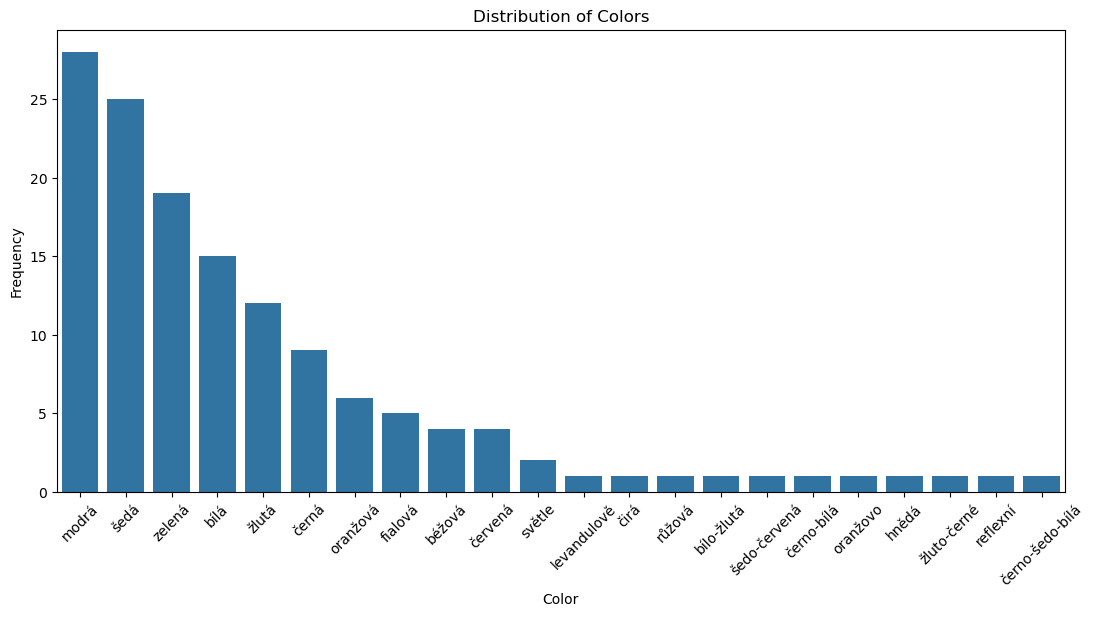

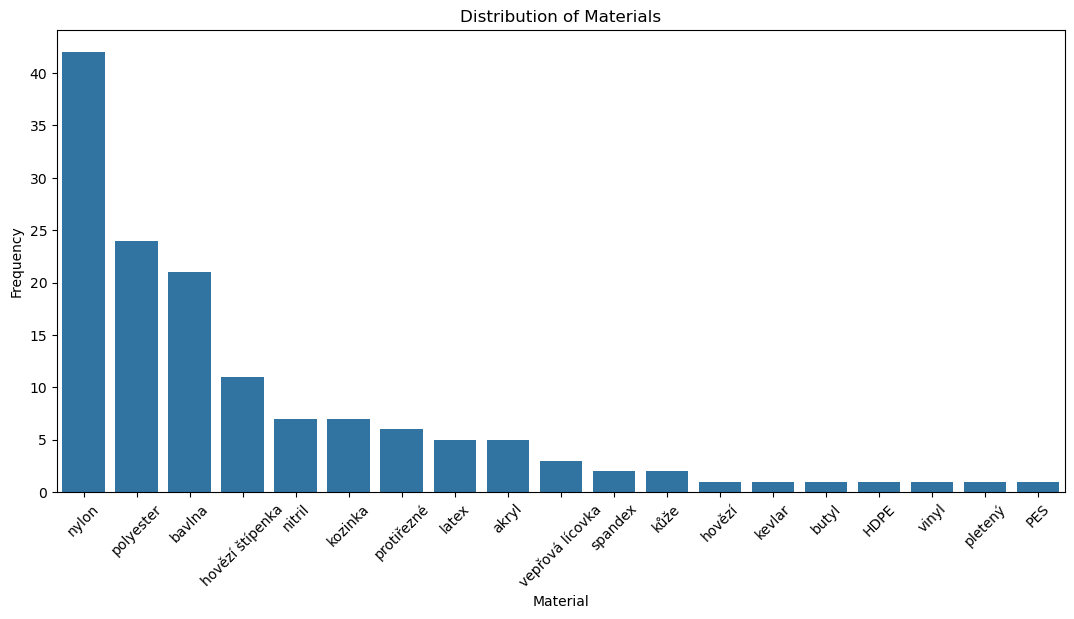

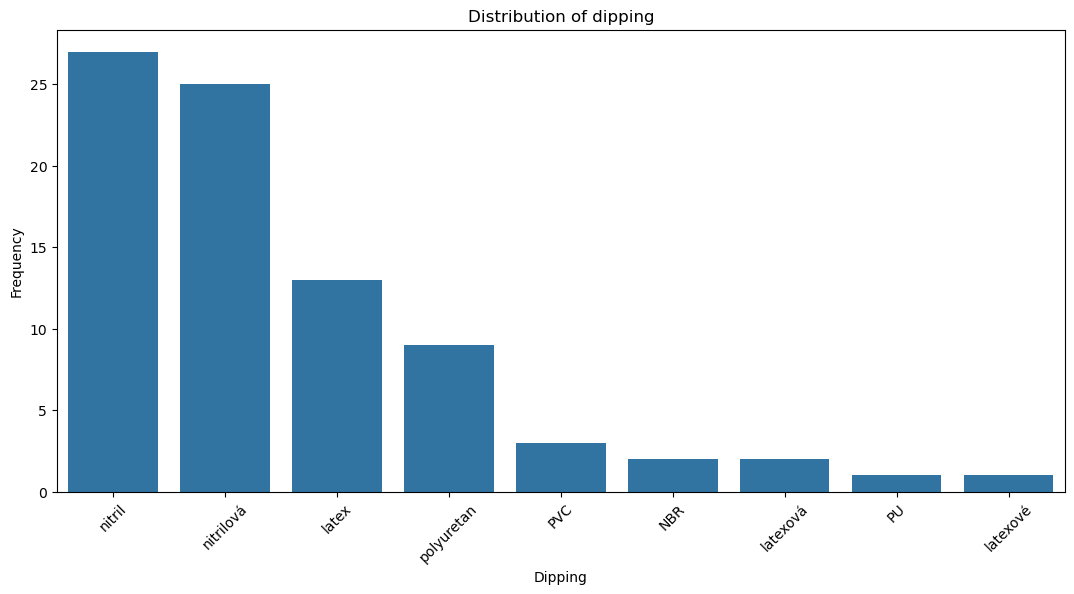

In [9]:
plt.figure(figsize=(13, 6))
sns.countplot(data=df, x='color', order=df['color'].value_counts().index)
plt.title('Distribution of Colors')
plt.xlabel('Color')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Create a bar chart for the 'material' column
plt.figure(figsize=(13, 6))
sns.countplot(data=df, x='material', order=df['material'].value_counts().index)
plt.title('Distribution of Materials')
plt.xlabel('Material')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(13, 6))
sns.countplot(data=df, x='dipping', order=df['dipping'].value_counts().index)
plt.title('Distribution of dipping')
plt.xlabel('Dipping')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

Na histogramoch môžeme vidieť distribúciu farby(color), materiálu(material) a máčania (dipping).

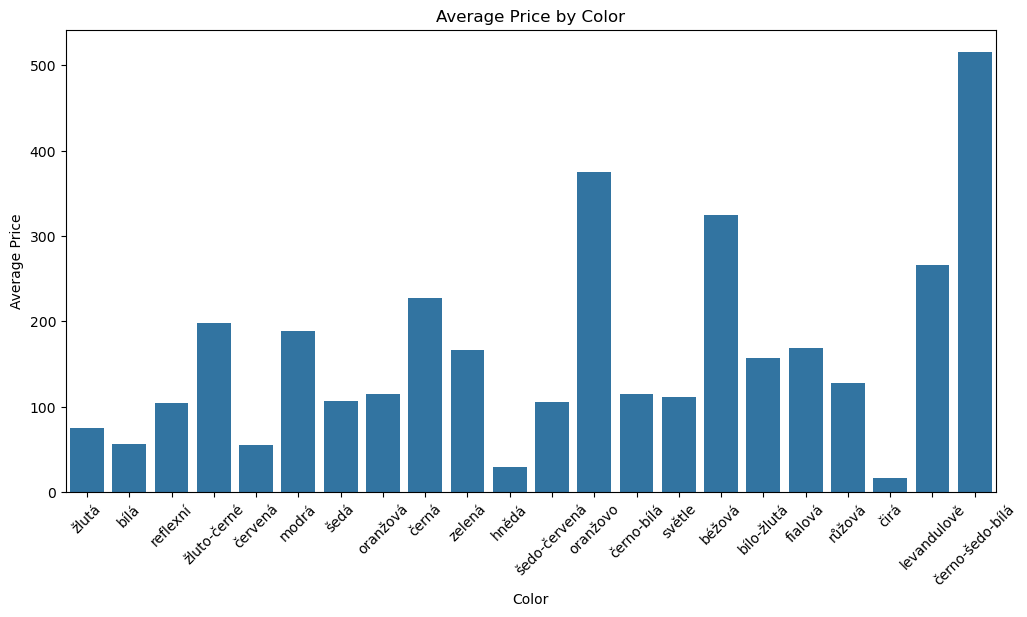

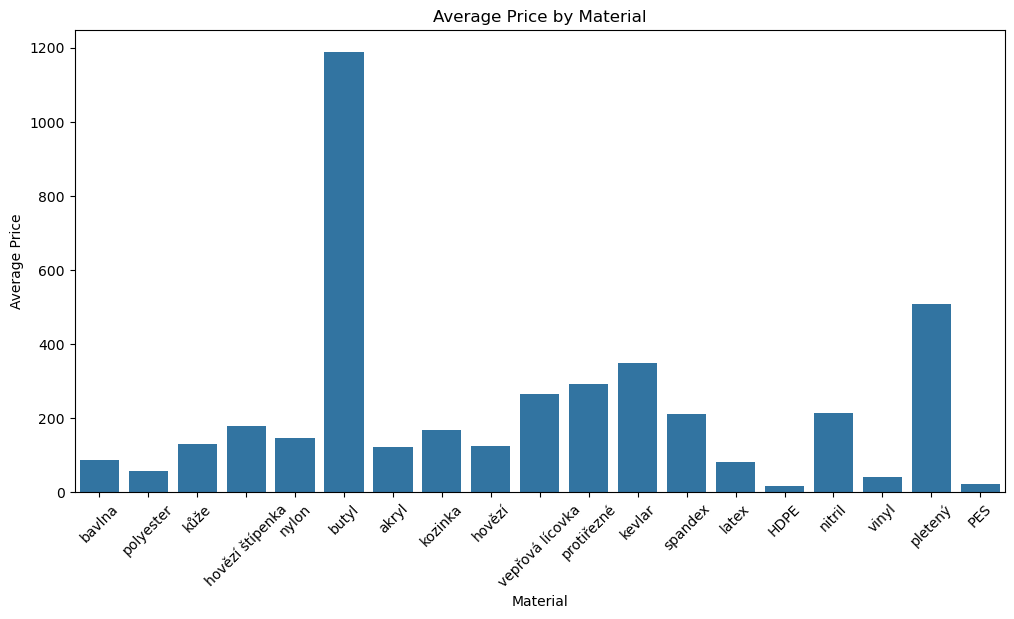

In [10]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='color', y='price', estimator='mean', errorbar=None)
plt.title('Average Price by Color')
plt.xlabel('Color')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='material', y='price', estimator='mean', errorbar=None)
plt.title('Average Price by Material')
plt.xlabel('Material')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.show()

Na prvom grafe môžeme vidieť závislosť medzi cenou a farbou. Na druhom grafe závislosť medzi cenou a materiálom.

Z podstaty môžeme vidieť, že prvý graf nemá v sebe nejakú súvislosť. Pre niektoré farby síce môžeme vidieť, že je vyššia cena, avšak tento jav by sa pravdepodobne vyeliminoval, keby sme mali obshiahlejšiu datovú sadu.

Druhý graf obsahuje zmysluplnejšie hodnoty, kde môžeme vidieť, že cena sa odvíja od druhu materiálu.

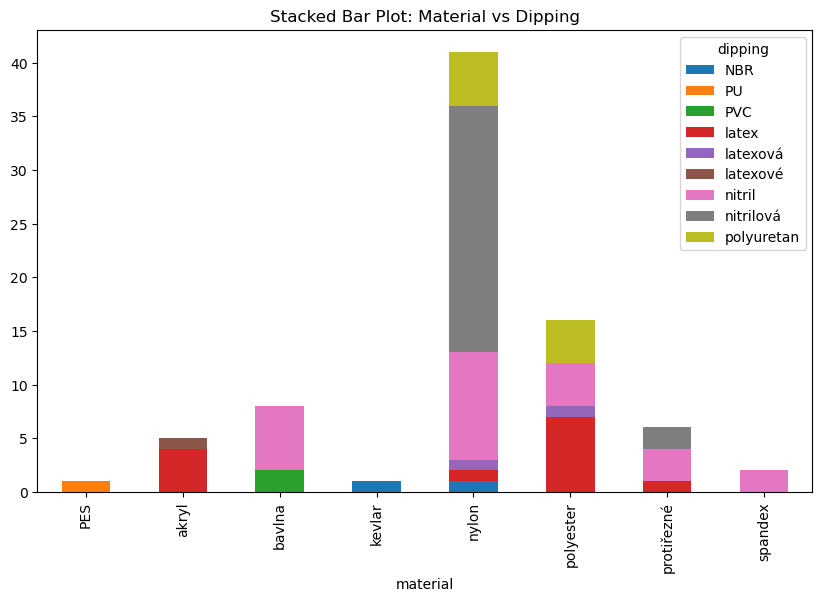

In [11]:
cross_tab = pd.crosstab(df['material'], df['dipping'])
cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Stacked Bar Plot: Material vs Dipping")
plt.show()

Graf stacked bar plot zobrazuje rozdelenie hodnôt atribútu máčania v závislosti od jednotlivých typov materiálu. Každý stĺpec reprezentuje konkrétny materiál a je rozdelený na rôzne časti podľa hodnôt atribútu máčania.

Nylon má najvyšší stĺpec, čo znamená, že je najviac zastúpený materiál. Najväčšiu časť stĺpca tvoria latexové a nitrilové máčania (dipping).

Na základe výšky stĺpcov je zrejmé, že niektoré druhy máčiania dominujú určitým materiáľom. Niektoré materiály sú málo máčané v našej sade ako kevlar, PES alebo spandex.

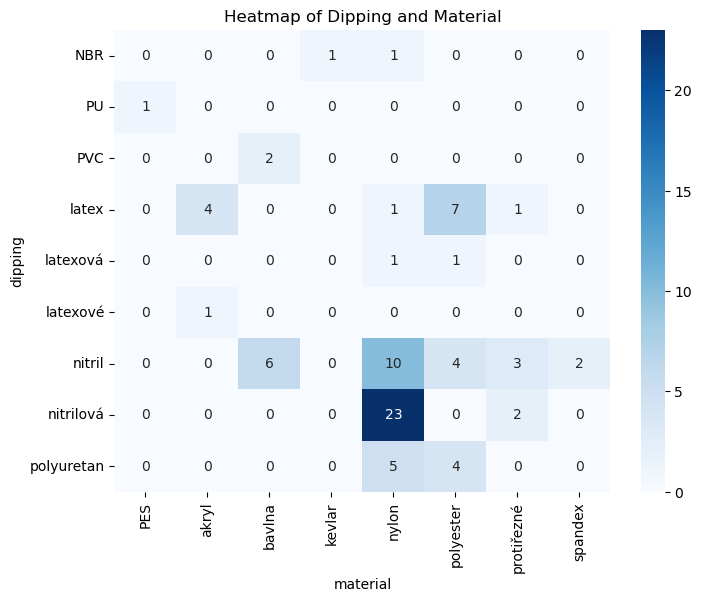

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(pd.crosstab(df['dipping'], df['material']), annot=True, fmt='d', cmap='Blues')
plt.title("Heatmap of Dipping and Material")
plt.show()

Graf heatmap zobrazuje vzťah medzi dvomi atribútmi máčanie a materiál. Každá bunka v matici reprezentuje početnosť konkrétnej kombinácie. Intenzita farby znázorňuje veľkosť hodnoty - čím tmavšia je farba, tým je vyššia početnosť.

Materiál nylon dosahuje pre rôzne máčania najväčší počet hodnôt, podobne ako v predchádzajúcom grafe. Najväčšia hodnota je pre nylon a nitrilové.

Najviac použité máčanie je latex, nitril a následne polyuretan.

V grafe môžeme vidieť, že rovnaké máčania sú rozprestrené do viac kategórií, kvôli rôznemu zaznačeniu slóv na e-shope (napríklad nitril, nitrilová).

## Analýza odlahlých hodnôt

Pri exploratívnej analýze a analýze grafov sme diskutovali prítomnosť odľahlých hodnôt. Tieto hodnoty nastaly vo všetkých kvantitatívnych atribútov. 

Pri atribúte počtu rukavíc v krabici(quantity_box) by bolo možné tento atribút buď celý odstrániť alebo sa len zbaviť odlahlých hodnôt, pretože väčšina atribútov dosahuje jednu hodnotu, konkrétne 12. 

Atribúty počet rukavíc v kartóne(quantity_carton) a ceny(price) obsahujú podobný typ odlahlých hodnôt, kde v oboch prípadoch nastal kus intervalu, v ktorom neboli žiadne vzorky. Tento jav môže byť spôsobený malým počtom dát v datovej sade, avšak nevidíme dôvod odstránenia odlahlých hodnôt pri týchto dvoch atribútov, keďže by nám z nich mohla zmiznúť podstatná čast informácie pri následnej analýze. 

## Analýza chýbajúcich hodnôt

In [13]:
# Count missing values per column
missing_per_column = df.isnull().sum()

# Count total missing values in the dataset
total_missing = df.isnull().sum().sum()

# Display missing values per column
print("Missing values per column:\n", missing_per_column)
print(f"Total missing values in the dataset: {total_missing}")

missing_proportion = df.isnull().mean()

# Display the proportions
print("\nProportion of missing values per column:\n", missing_proportion)

# Count the number of rows with at least one missing value
rows_with_missing = df.isnull().any(axis=1).sum()

# Count rows with more than one missing value
rows_with_multiple_missing = df.isnull().sum(axis=1).gt(1).sum()

print("")
print(f"Rows with at least one missing value: {rows_with_missing}")
print(f"Rows with more than one missing value: {rows_with_multiple_missing}")

Missing values per column:
 url                 0
name                0
price               0
quantity_box       23
quantity_carton    23
color              10
material            8
dipping            67
dtype: int64
Total missing values in the dataset: 131

Proportion of missing values per column:
 url                0.000000
name               0.000000
price              0.000000
quantity_box       0.153333
quantity_carton    0.153333
color              0.066667
material           0.053333
dipping            0.446667
dtype: float64

Rows with at least one missing value: 82
Rows with more than one missing value: 26


V datovej sade sa celkovo nachádza 131 chýbajúcih hodnôt. Tento počet je rozdelený do niekoľkých stĺpcov, pričom každému stĺpcu chýba rozlišné množstvo hodnôt.

Najviac atribútov chýba pre kategóriu dipping, kde atribútov chýba skoro 50 %. Následuje quantity_box, quantity_carton, color a material.

82 riadkov obsahuje aspoň jednu chýbajúcu hodnotu.
26 riadkov má viac než jednu chýbajúcu hodnotu.

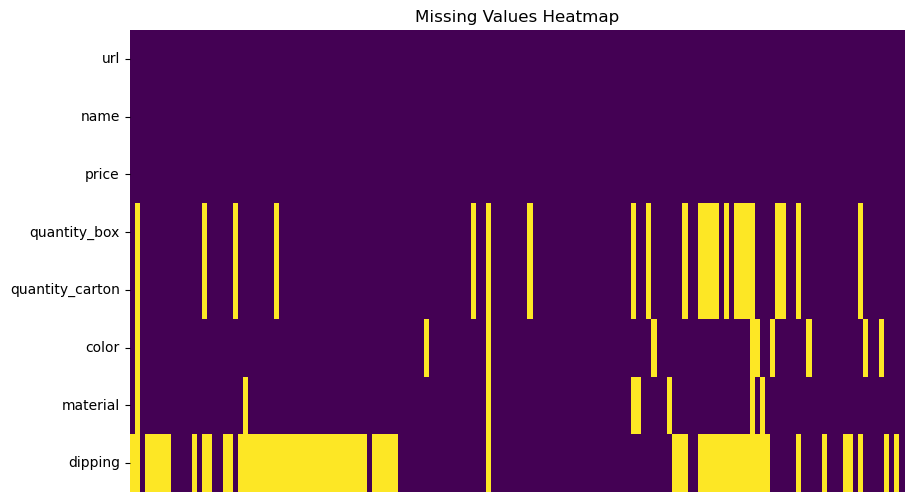

In [14]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull().T, cbar=False, cmap='viridis', xticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

Na grafe môžeme vidieť vizualizované chýbajúce dáta v datovej sade.

V datovej sade sa nachádza značné množstvo chýbajúcich hodnôt. Tieto chýbajúce hodnoty je možné riešiť rôznymi spôsobmi. Jednou z možností je odstránenie riadkov s chýbajúcimi hodnotami. Ďalšie riešenie je doplneniť chýbajúce hodnoty. Pre numerické atribúty je bežné doplniť tieto hodnoty priemernou hodnotou alebo mediánom, v závislosti od distribúcie dát. Pre kategorizované atribúty by sme mohli zvážiť doplnění najčastejšej hodnoty.

## Korelačná analýza

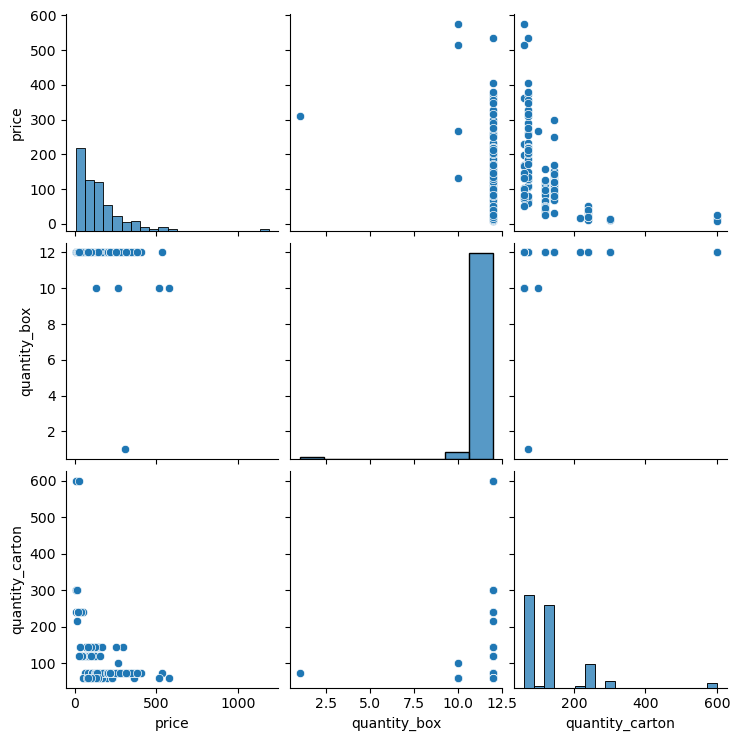

In [15]:
numeric_columns = df.select_dtypes(include=[np.number]).columns 
sns.pairplot(df[numeric_columns])
plt.show()

Graf zobrazuje párovú analýzu medzi tromi numerickými atribútmi price, quantity_box a quantity_carton. 

Tento graf kombinuje bodové grafy s histogramami pozdĺž diagonály. Histogramy poukazujú na nerovnomerné rozdelenia dát medzi jednotlivými premennými.  Bodové grafy vizuálne naznačujú negatívne vzťahy medzi cenou a množstvami (v krabici aj kartóne).

Táto analýza poskytuje vizuálny základ pre následné výpočty korelačných koeficientov (napr. Pearson alebo Spearman).

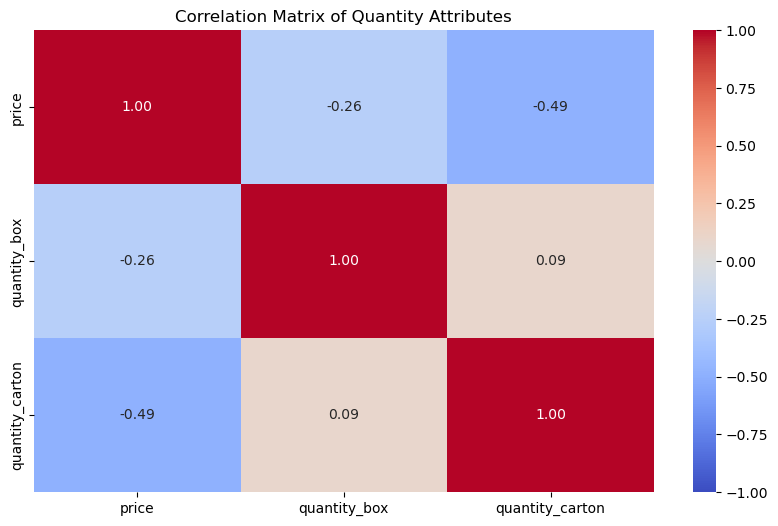

In [16]:
correlation_matrix = df[numeric_columns].corr()

# Plot the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Quantity Attributes')
plt.show()

Na grafe môžeme vidieť výsledky Pearsonovej korelácie.  
Vzťah medzi price a quantity_box je slabý negatívny lineárny vzťah (-0.26), čo naznačuje, že s rastúcou cenou sa počet rukavíc v krabici mierne znižuje.

Podobne, vzťah medzi price a quantity_carton je tiež negatívny lineárny vzťah (-0.49), čo znamená, že s vyššou cenou sa množstvo rukavíc v kartóne znižuje. Tento vzťah je o niečo silnejší ako v prípade quantity_box.

Vzťah medzi quantity_box a quantity_carton je veľmi slabý (0.09), čo naznačuje, že medzi počtom rukavíc v krabici a kartóne neexistuje významný lineárny vzťah.

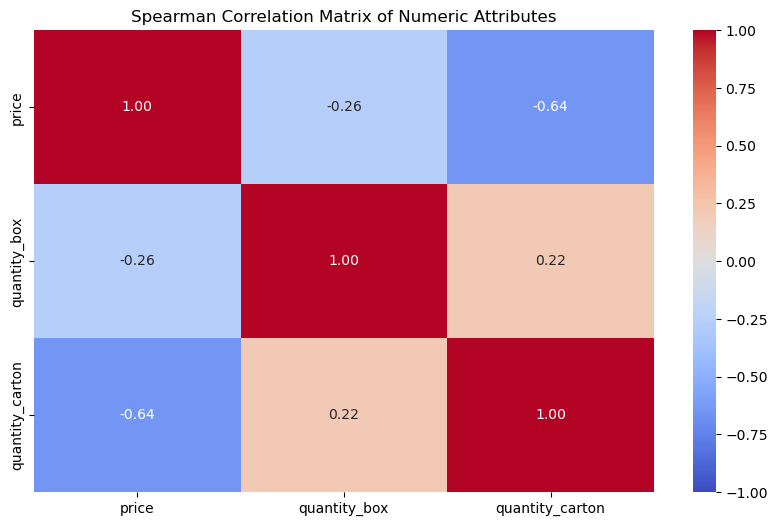

In [17]:
correlation_matrix = df[numeric_columns].corr(method='spearman')

# Plot the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix of Numeric Attributes')
plt.show()

Teraz zanalyzujeme výsledky Spearmanovej korelácie.  
Vzťah medzi price a quantity_box dosahuje slabý negatívny monotónny vzťah (-0.264). Tento vzťah naznačuje, že s rastúcou cenou sa počet rukavíc v krabici znižuje, ale nemusí byť striktne lineárny.


Vzťah medzi price a quantity_carton je silnejší negatívny monotónny vzťah (-0.643), čo naznačuje, že s rastúcou cenou počet rukavíc v kartóne klesá.


Vzťah medzi quantity_box a quantity_carton je slabo pozitívny monotónny vzťah (0.219), čo znamená, že keď jeden parameter rastie, druhý má tendenciu rastúť, aj keď tento vzťah nie je silný.


Všetky vzťahy sú silnejšie ako pri Pearsonovej korelácii, čo naznačuje, že monotónnosť je lepším indikátorom vzťahov medzi týmito atribútmi ako ich lineárnosť.

Z korelačnej analýzy sme dospeli k záveru, že medzi cenou a počtom rukavíc v kartóne existuje silnejší vzťah, ktorý je negatívny. S rastúcou cenou sa počet rukavíc v kartóne znižuje, čo naznačuje, že tento vzťah je výraznejší v porovnaní s ostatnými atribútmi. Pre ostatné atribúty, ako sú quantity_box a quantity_carton, nebol vzťah medzi nimi významný, či už lineárny (Pearson) alebo monotónny (Spearman).

# 2.časť

Pre dolovací algoritmus nebude podstatné URL ani názov výrobku, preto tieto atribúty z dátovej sady odstránime. Urobíme to však až na konci, aby sme boli schopní dopĺňať hodnoty pri analýze chýbajúcich hodnôt.

Pri exploratívnej analýze sme zistili, že atribúty `quantity_box` a `quantity_carton` majú 23 chýbajúcich hodnôt. Keď si vypíšeme všetky vzorky, kde chýba jeden z týchto stĺpcov, zistíme, že pre oba atribúty chýbajú dáta u rovnakých vzoriek.

Tieto vzorky z dátovej sady vypustíme.

In [18]:
df[df['quantity_box'].isna() | df['quantity_carton'].isna()].shape

(23, 8)

In [19]:
df = df.dropna(subset=['quantity_box', 'quantity_carton'])
df

,url,name,price,quantity_box,quantity_carton,color,material,dipping
0,https://www.ardon.cz/kombinovane-rukavice-ardo...,Kombinované rukavice ARDON®ELTON,69.43,12.0,72.0,žlutá,bavlna,NaN
2,https://www.ardon.cz/macene-rukavice-ardonsafe...,Máčené rukavice ARDON®RANDY,43.44,12.0,120.0,bílá,polyester,latex
3,https://www.ardon.cz/kombinovane-rukavice-ardo...,Kombinované rukavice ARDON®ELTON,60.50,12.0,72.0,žlutá,bavlna,NaN
4,https://www.ardon.cz/zimni-rukavice-ardon-r-ho...,Zimní rukavice ARDON®HOBBY REFLEX WINTER,104.15,12.0,120.0,reflexní,kůže,NaN
5,https://www.ardon.cz/svarecske-rukavice-ardon-...,Svářečské rukavice ARDON®KIRK,168.41,12.0,60.0,žlutá,hovězí štípenka,NaN
...,...,...,...,...,...,...,...,...
145,https://www.ardon.cz/macene-rukavice-ardonsafe...,Máčené rukavice ARDON®DICK BASIC,24.80,12.0,120.0,NaN,polyester,latex
146,https://www.ardon.cz/svarecske-rukavice-weldas...,Svářečské rukavice WELDAS 10-2050,515.74,10.0,60.0,černo-šedo-bílá,hovězí štípenka,NaN
147,https://www.ardon.cz/zimni-rukavice-ardon-r-wi...,Zimní rukavice ARDON®Winfine,98.98,12.0,60.0,světle,akryl,latexové
148,https://www.ardon.cz/svarecske-rukavice-weldas...,Svářečské rukavice Weldas® 10-1003,575.25,10.0,60.0,béžová,vepřová lícovka,NaN


In [20]:
df.loc[df['url'] == "https://www.ardon.cz/macene-rukavice-ardonsafety-dick-basic-08-m", 'color'] = 'černo-bílá'
df.loc[df['url'] == "https://www.ardon.cz/macene-rukavice-ardonsafety-nitrax-basic-10-xl", 'color'] = 'černo-bílá'
df.loc[df['url'] == "https://www.ardon.cz/macene-rukavice-ardon-r-green-touch-07-s-s-prodejni-etiketou-fialova", 'color'] = 'modrá'
df.loc[df['url'] == "https://www.ardon.cz/macene-rukavice-ardon-r-petrax", 'color'] = 'oranžová'
df.loc[df['url'] == "https://www.ardon.cz/tepelne-odolne-rukavice-activarmr-r-42-474-09-l-ex-crusader", 'color'] = 'šedá'


df.loc[df['url'] == "https://www.ardon.cz/jednorazove-rukavice-semperguard-style", 'color'] = 'černá'
df.loc[df['url'] == "https://www.ardon.cz/macene-rukavice-ardonsafety-houston-modra", 'color'] = 'modrá'
df.loc[df['url'] == "https://www.ardon.cz/atg-r-macene-rukavice-maxiflex-r-ultimatetm-42-875-ad-apt", 'color'] = 'černo-bílá'
df.loc[df['url'] == "https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-ultratm-44-6745f", 'color'] = 'černá'
df.loc[df['url'] == "https://www.ardon.cz/macene-rukavice-ardonsafety-perry-uni-s-prodejni-etiketou-doprodej", 'color'] = 'bílá'

df.loc[df['url'] == "https://www.ardon.cz/atg-r-protirezne-rukavice-maxicut-r-oiltm-44-505", 'material'] = 'nylon'
df.loc[df['url'] == "https://www.ardon.cz/chemicke-rukavice-alphatec-r-37-676-ex-sol-vex-r-07-s", 'material'] = 'polyester'
df.loc[df['url'] == "https://www.ardon.cz/macene-rukavice-ardonsafety-ray", 'material'] = 'polyester'
df.loc[df['url'] == "https://www.ardon.cz/zimni-rukavice-ardonsafety-rocky-winter", 'material'] = 'bavlna'

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127 entries, 0 to 149
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   url              127 non-null    object 
 1   name             127 non-null    object 
 2   price            127 non-null    float64
 3   quantity_box     127 non-null    float64
 4   quantity_carton  127 non-null    float64
 5   color            127 non-null    object 
 6   material         127 non-null    object 
 7   dipping          76 non-null     object 
dtypes: float64(3), object(5)
memory usage: 8.9+ KB


Teraz môžeme vypustiť atribúty `name` a `url`.

Upravená dátová sada obsahuje 3 kvantitatívne a 3 kategorické atribúty.

In [21]:
df= df.drop(columns=['url', 'name'])
df

,price,quantity_box,quantity_carton,color,material,dipping
0,69.43,12.0,72.0,žlutá,bavlna,NaN
2,43.44,12.0,120.0,bílá,polyester,latex
3,60.50,12.0,72.0,žlutá,bavlna,NaN
4,104.15,12.0,120.0,reflexní,kůže,NaN
5,168.41,12.0,60.0,žlutá,hovězí štípenka,NaN
...,...,...,...,...,...,...
145,24.80,12.0,120.0,černo-bílá,polyester,latex
146,515.74,10.0,60.0,černo-šedo-bílá,hovězí štípenka,NaN
147,98.98,12.0,60.0,světle,akryl,latexové
148,575.25,10.0,60.0,béžová,vepřová lícovka,NaN


Teraz vyriešme 51 chýbajúcich hodnôt atribútu `dipping`. 
Avšak najprv si všimnime, že `dipping` má 5 hodnôt: nitril - nitrilová a latex - latexová - latexové, ktoré je možné zlúčiť do dvoch.

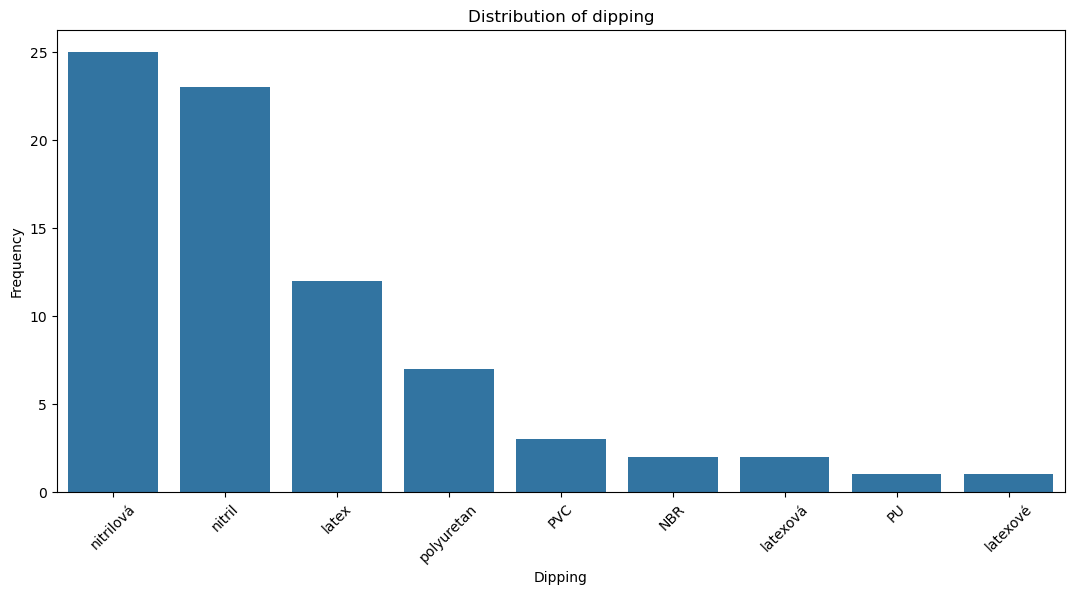

In [22]:
plt.figure(figsize=(13, 6))
sns.countplot(data=df, x='dipping', order=df['dipping'].value_counts().index)
plt.title('Distribution of dipping')
plt.xlabel('Dipping')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

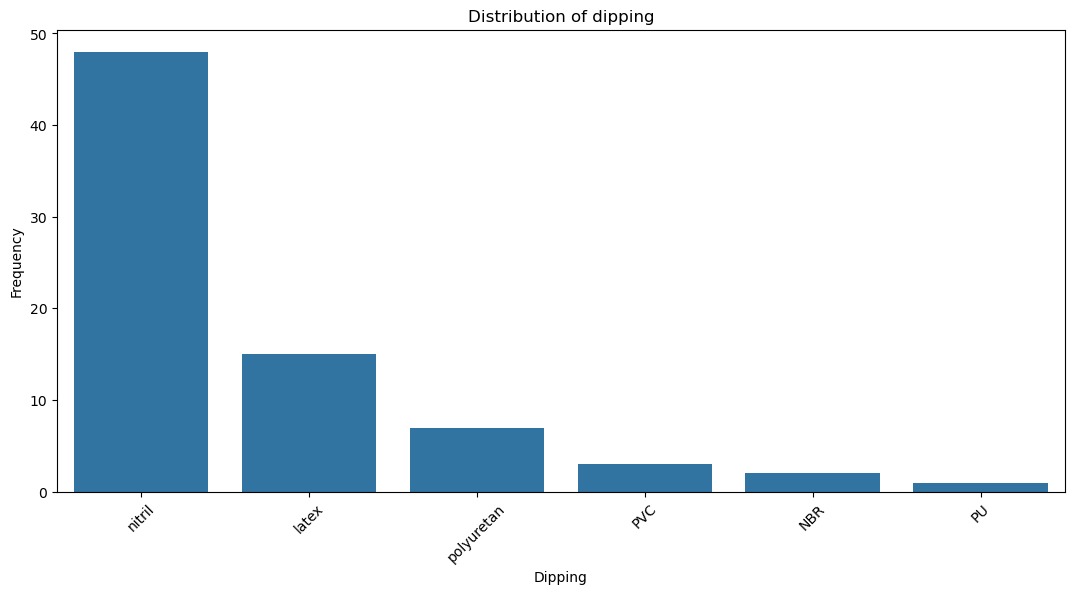

In [23]:
df.loc[df['dipping'] == "nitrilová", 'dipping'] = 'nitril'
df.loc[df['dipping'] == "latexová", 'dipping'] = 'latex'
df.loc[df['dipping'] == "latexové", 'dipping'] = 'latex'

plt.figure(figsize=(13, 6))
sns.countplot(data=df, x='dipping', order=df['dipping'].value_counts().index)
plt.title('Distribution of dipping')
plt.xlabel('Dipping')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

Teraz vyplníme všetky chýbajúce hodnoty najčastejšou hodnotou –- nitril. Teraz nebudú žiadne atribúty s chýbajúcimi hodnotami.

In [24]:
df['dipping'] = df['dipping'].fillna('nitril')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            127 non-null    float64
 1   quantity_box     127 non-null    float64
 2   quantity_carton  127 non-null    float64
 3   color            127 non-null    object 
 4   material         127 non-null    object 
 5   dipping          127 non-null    object 
dtypes: float64(3), object(3)
memory usage: 6.9+ KB


Teraz v upravenej datovej sade zanalyzujeme odlahlé hodnoty.

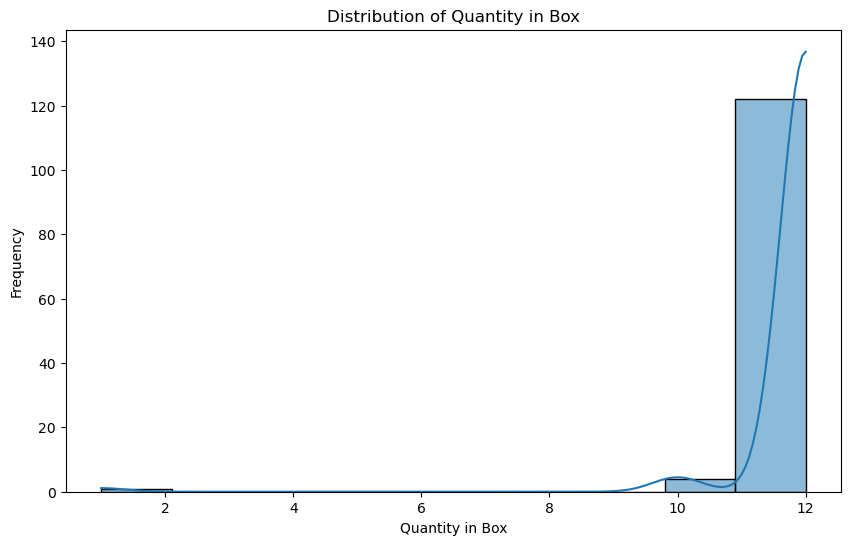

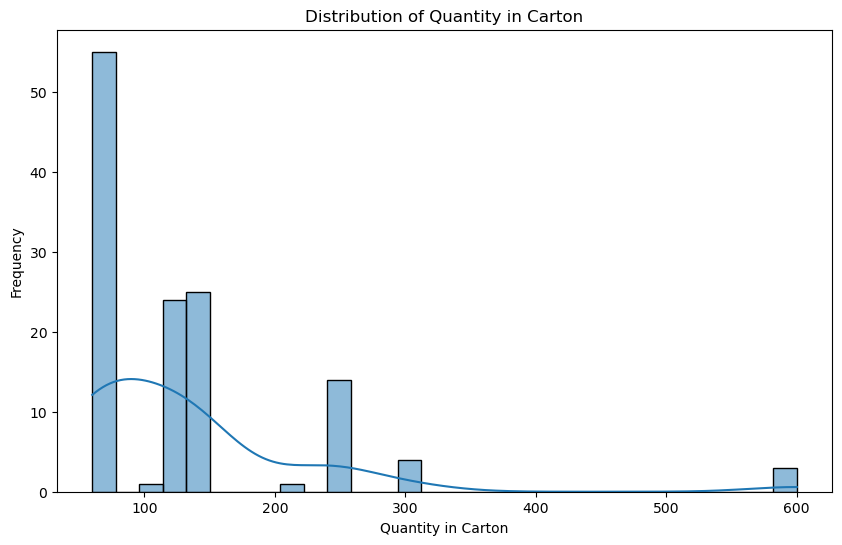

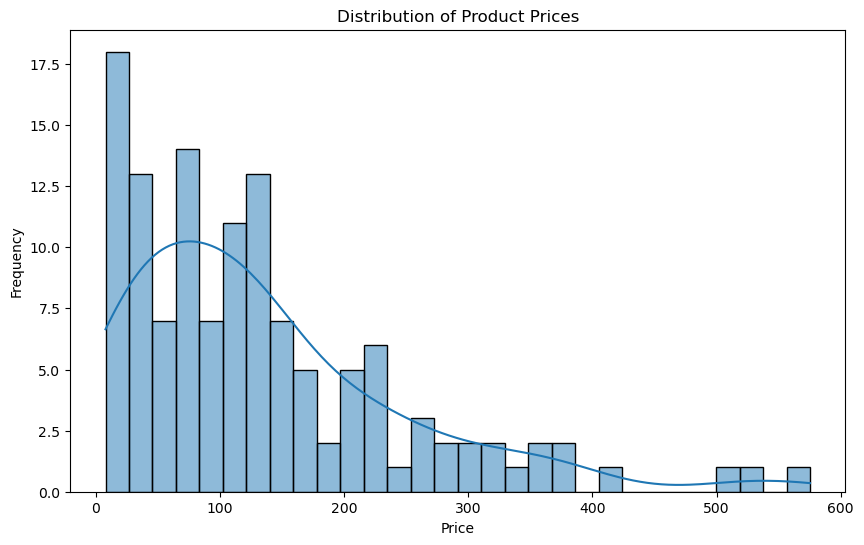

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['quantity_box'], kde=True, bins=10)
plt.title('Distribution of Quantity in Box')
plt.xlabel('Quantity in Box')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['quantity_carton'], kde=True, bins=30)
plt.title('Distribution of Quantity in Carton')
plt.xlabel('Quantity in Carton')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30)
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

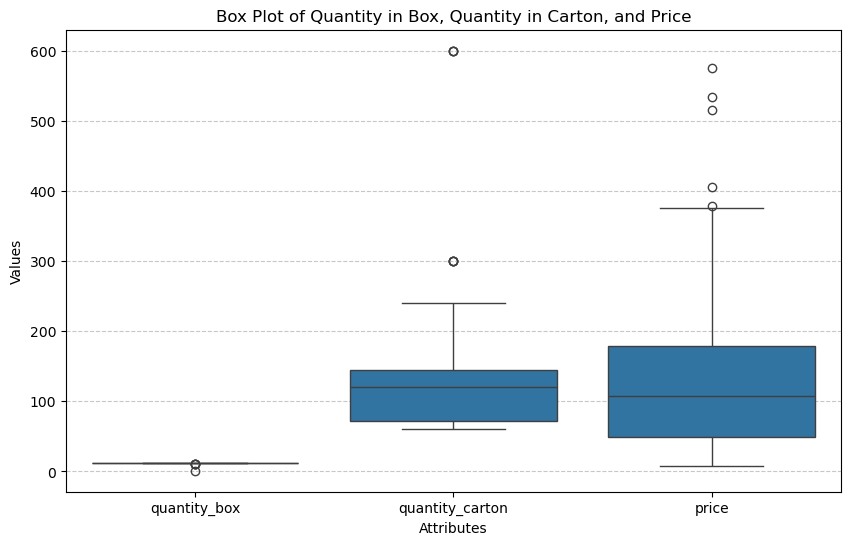

In [26]:
df_melted = df[['quantity_box', 'quantity_carton', 'price']].melt(var_name='Attribute', value_name='Value')

# Create a box plot with a log scale on the y-axis
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attribute', y='Value', data=df_melted)

# Set the title and labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Box Plot of Quantity in Box, Quantity in Carton, and Price')
plt.xlabel('Attributes')
plt.ylabel('Values')

plt.show()

Z histogramov a box plot grafu sme analyzovali odľahlé hodnoty pre atribúty quantity_box a quantity_carton. Pre atribút quantity_carton sme identifikovali 3 odľahlé hodnoty. Rozhodli sme sa ich ponechať, pretože ich odstránením by sme mohli prísť o dôležitú informáciu, ktorá môže byť relevantná pre analýzu.

Naopak, pre atribút quantity_box sa nachádza odľahlá hodnota na hodnote 1. Táto hodnota sa javí ako málo informatívna pre model, pretože výrazne vyčnieva zo zvyšku dát a neodráža bežné hodnoty tohto atribútu. Z tohto dôvodu sme sa rozhodli ju z modelu vylúčiť.

Konkrétny počet odlahlých hodnôt je vyobrazený v nasledujúcej bunke:

In [27]:
outlier_count = df[(df['quantity_carton'] >= 580) & (df['quantity_carton'] <= 600)].shape[0]

print(f"Number of values for quantity_carton in the range 580 to 600: {outlier_count}")

outlier_count = df[(df['quantity_box'] >= 0) & (df['quantity_box'] <= 3)].shape[0]

print(f"Number of values for quantity_box in the range 1 to 3: {outlier_count}")

Number of values for quantity_carton in the range 580 to 600: 3
Number of values for quantity_box in the range 1 to 3: 1


In [28]:
row_to_delete = df[(df['quantity_box'] >= 1) & (df['quantity_box'] <= 3)].index

# Drop these rows
df = df.drop(row_to_delete)
df = df.reset_index(drop=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            126 non-null    float64
 1   quantity_box     126 non-null    float64
 2   quantity_carton  126 non-null    float64
 3   color            126 non-null    object 
 4   material         126 non-null    object 
 5   dipping          126 non-null    object 
dtypes: float64(3), object(3)
memory usage: 6.0+ KB


### 1. varianta - diskretizácia kvantitativních atribútov
- máme kvantitatívne atribúty price, quantity_box a quantity_carton

Keďže chceme výsledky aj na niečom demonštrovať, tak price atribút necháme nezmenený a zdiskretujeme quantity_carton a quantity_box.

In [29]:
df_variant1 = df.copy(deep=True)
df_variant1['quantity_carton_discretized'] = pd.cut(df_variant1['quantity_carton'], bins=3, labels=['Low', 'Medium', 'High'])
df_variant1['quantity_box_discretized'] = pd.cut(df_variant1['quantity_box'], bins=2, labels=['Low', 'High'])

df_variant1 = df_variant1.drop(columns=['quantity_carton'])
df_variant1 = df_variant1.drop(columns=['quantity_box'])

print("First variant - Discretized dataset:")
df_variant1

First variant - Discretized dataset:


,price,color,material,dipping,quantity_carton_discretized,quantity_box_discretized
0,69.43,žlutá,bavlna,nitril,Low,High
1,43.44,bílá,polyester,latex,Low,High
2,60.50,žlutá,bavlna,nitril,Low,High
3,104.15,reflexní,kůže,nitril,Low,High
4,168.41,žlutá,hovězí štípenka,nitril,Low,High
...,...,...,...,...,...,...
121,24.80,černo-bílá,polyester,latex,Low,High
122,515.74,černo-šedo-bílá,hovězí štípenka,nitril,Low,Low
123,98.98,světle,akryl,latex,Low,High
124,575.25,béžová,vepřová lícovka,nitril,Low,Low


Prvá varianta s diskrétizovanými atribútmi je vhodná pre dolovacie algoritmy ako SMOTE, pretože SMOTE pracuje efektívne s kategorizovanými dátami. Diskretizácia atribútov ako quantity_carton a quantity_box zjednodušuje modelovanie dolovaciemu algoritmu.

### 2. varianta - transformácia kategorických atribútov na numerické atribúty
- máme za úlohu štandardizovať všetky numerické hodnoty
- ďaľej previesť kategorické atribúty na numerické hodnoty

Pre prevedenie kategorických atribútov sme použili One hot Encoding.

In [30]:
df_one_hot=df.copy(deep=True)

In [31]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# All categorical columns
categorical_columns = ['color', 'material', 'dipping']

# All numerical columns
numerical_columns = ['price', 'quantity_box', 'quantity_carton']

# In preprocessor we transform numerical columns to standart scale and
# to categorical columns we apply one hot encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(feature_range=(-1, 1)), numerical_columns),
        ('cat', OneHotEncoder(sparse_output=False), categorical_columns) 
    ],
)
# Now just apply the transformation
df_transformed = preprocessor.fit_transform(df_one_hot)

# Now we want to collect all columns to then create the new variant of dataset
numerical_transformed_columns = numerical_columns
categorical_transformed_columns = preprocessor.transformers_[1][1].get_feature_names_out(categorical_columns)
all_column_names = numerical_transformed_columns + list(categorical_transformed_columns)

# Create a new DataFrame from the transformed data
df_transformed_df = pd.DataFrame(df_transformed, columns=all_column_names)

print(df_transformed_df.head())

      price  quantity_box  quantity_carton  color_béžová  color_bílo-žlutá  \
0 -0.782940           1.0        -0.955556           0.0               0.0   
1 -0.874551           1.0        -0.777778           0.0               0.0   
2 -0.814417           1.0        -0.955556           0.0               0.0   
3 -0.660557           1.0        -0.777778           0.0               0.0   
4 -0.434050           1.0        -1.000000           0.0               0.0   

   color_bílá  color_fialová  color_hnědá  color_modrá  color_oranžovo  ...  \
0         0.0            0.0          0.0          0.0             0.0  ...   
1         1.0            0.0          0.0          0.0             0.0  ...   
2         0.0            0.0          0.0          0.0             0.0  ...   
3         0.0            0.0          0.0          0.0             0.0  ...   
4         0.0            0.0          0.0          0.0             0.0  ...   

   material_polyester  material_protiřezné  material_spa

Keďže všetky atribúty sú numerické, druhá varianta je vhodná pre dolovacie algoritmy ako PCA, ktoré vyžadujú numerické vstupy. Normalizácia a transformácia kategorizovaných atribútov na numerické hodnoty zjednodušuje modelovanie a analýzu pomocou týchto algoritmov.

In [32]:
# Now just transform dataframes to csv files for both variants
df_variant1.to_csv('First_variant.csv', index=False)
df_transformed_df.to_csv('Second_variant.csv', index=False)